## Setup and Training

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 43.5/235.7 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mkdir /content/datasets

In [ ]:
!cp "/content/drive/MyDrive/SmartDronesFinal/Thermal Dogs and People.v1-resize-416x416.yolov8.zip" "/content/datasets/"

In [ ]:
!mv "/content/datasets/Thermal Dogs and People.v1-resize-416x416.yolov8.zip" "/content/datasets/data.zip"

In [ ]:
!unzip "/content/datasets/data.zip" -d "/content/datasets/"

Archive:  /content/datasets/data.zip
 extracting: /content/datasets/README.dataset.txt  
 extracting: /content/datasets/README.roboflow.txt  
 extracting: /content/datasets/data.yaml  
   creating: /content/datasets/test/
   creating: /content/datasets/test/images/
 extracting: /content/datasets/test/images/IMG_0002 4_jpg.rf.6d1c60bf9f8779f13291c0547ea1ff70.jpg  
 extracting: /content/datasets/test/images/IMG_0006 5_jpg.rf.cd46e6a862d6ffb7fce6795067ce7cc7.jpg  
 extracting: /content/datasets/test/images/IMG_0009_jpg.rf.ecdb212f7d7796e682a87e2e1d6e907e.jpg  
 extracting: /content/datasets/test/images/IMG_0012 2_jpg.rf.4c8e033ea0189ebd28c4e3751edd7a6a.jpg  
 extracting: /content/datasets/test/images/IMG_0022_jpg.rf.c89662890a0f5d8a915677ed21165d2b.jpg  
 extracting: /content/datasets/test/images/IMG_0023 3_jpg.rf.ac45d9a3e591d1377f50b25c2415a5b7.jpg  
 extracting: /content/datasets/test/images/IMG_0024 2_jpg.rf.7f92f2bd29719c59c66c307fe5c3df44.jpg  
 extracting: /content/datasets/test/im

In [ ]:
%cd /content/datasets/

/content/datasets


In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data=data.yaml epochs=15 imgsz=416 plots=True

100% 21.5M/21.5M [00:00<00:00, 510MB/s]
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=data.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=

In [ ]:
!cp -r "/content/datasets/runs/detect/" "/content/drive/MyDrive/SmartDronesFinal/train1"

## Results

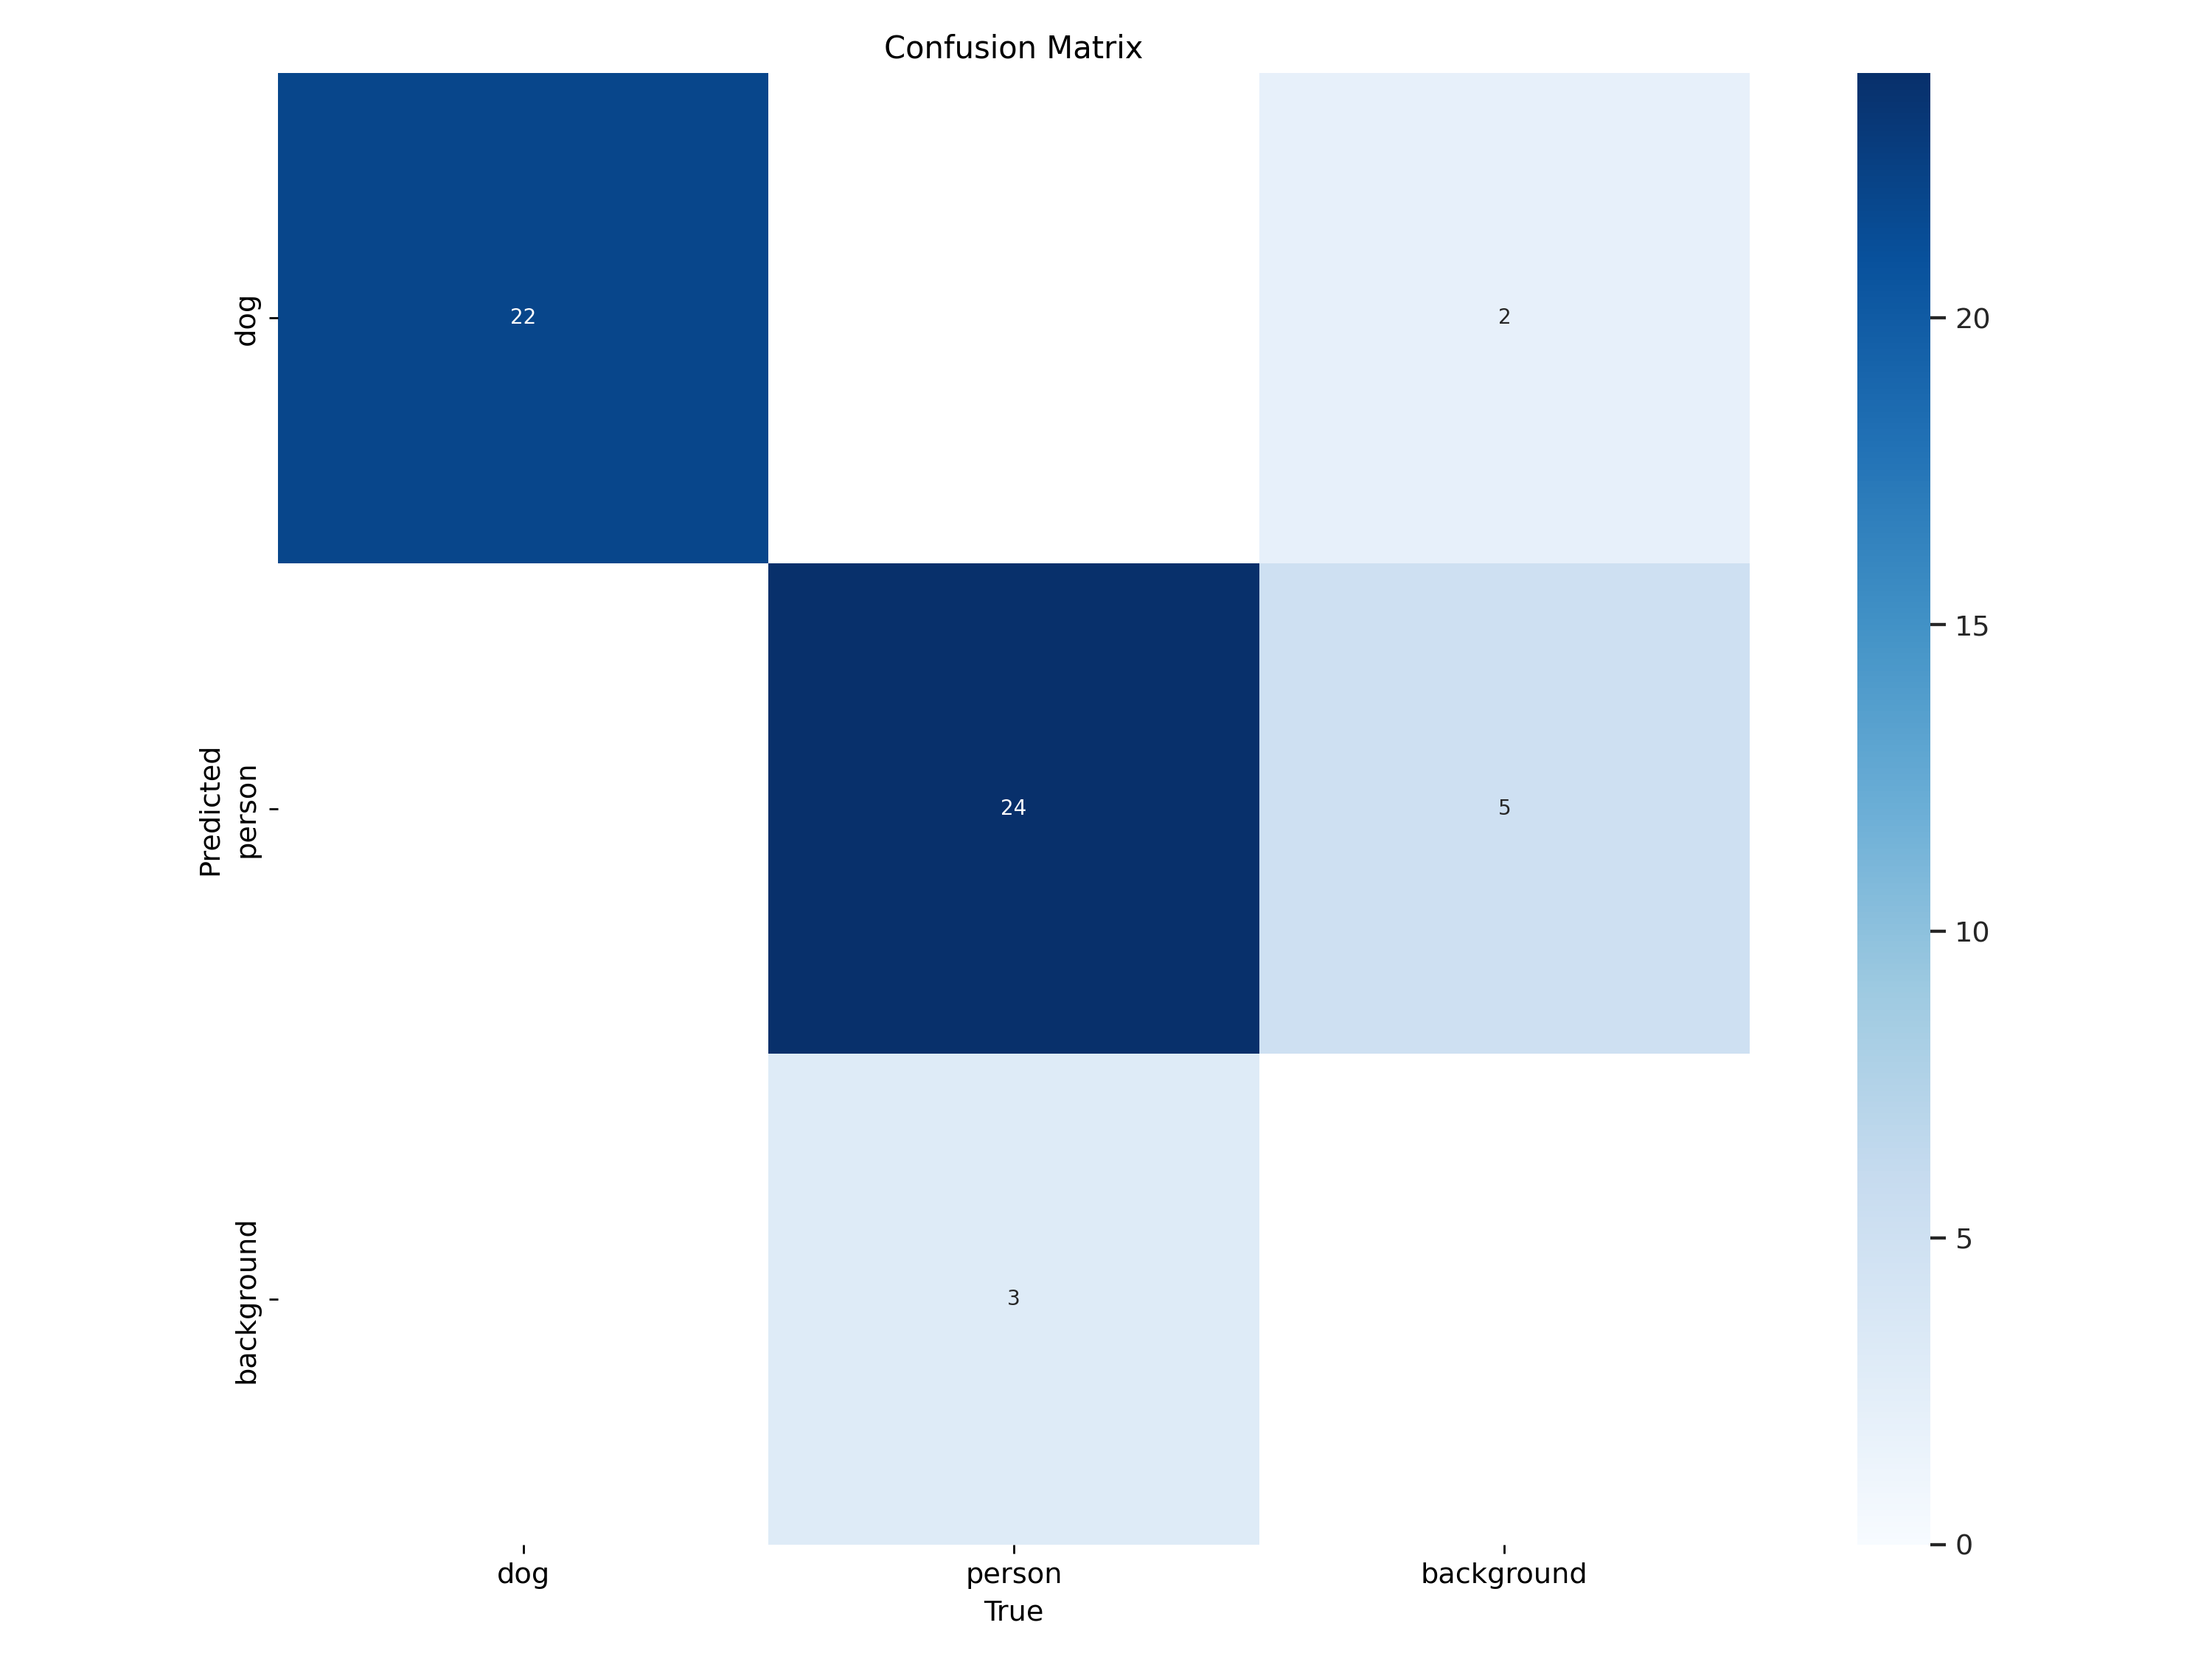

In [ ]:
Image(filename='/content/drive/MyDrive/SmartDronesFinal/train1/train/confusion_matrix.png', width=600)

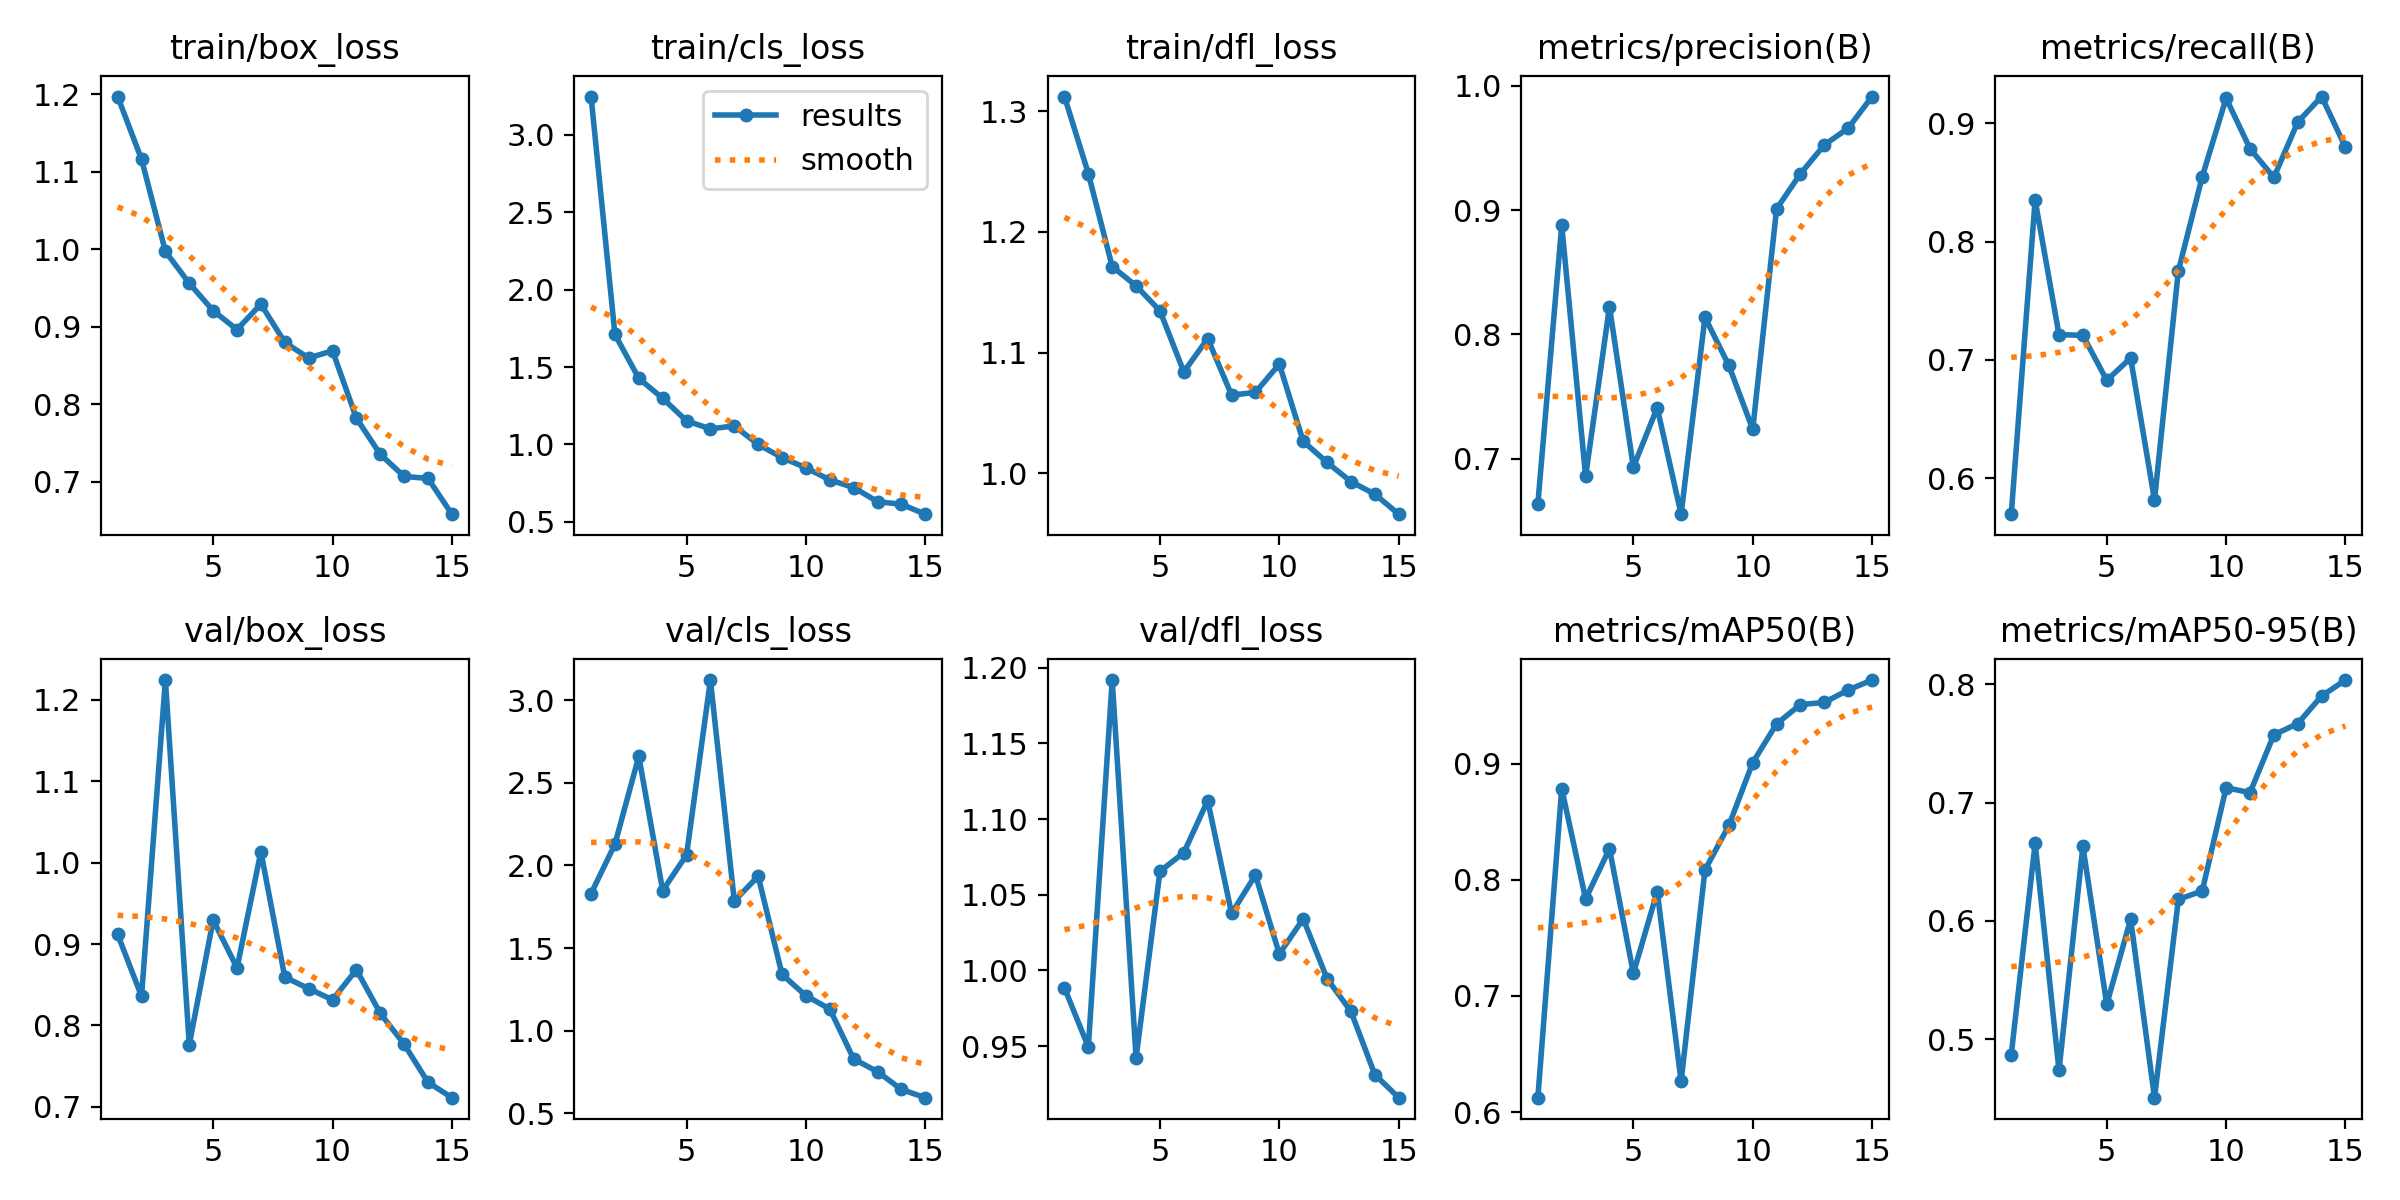

In [ ]:
Image(filename='/content/datasets/runs/detect/train/results.png', width=600)

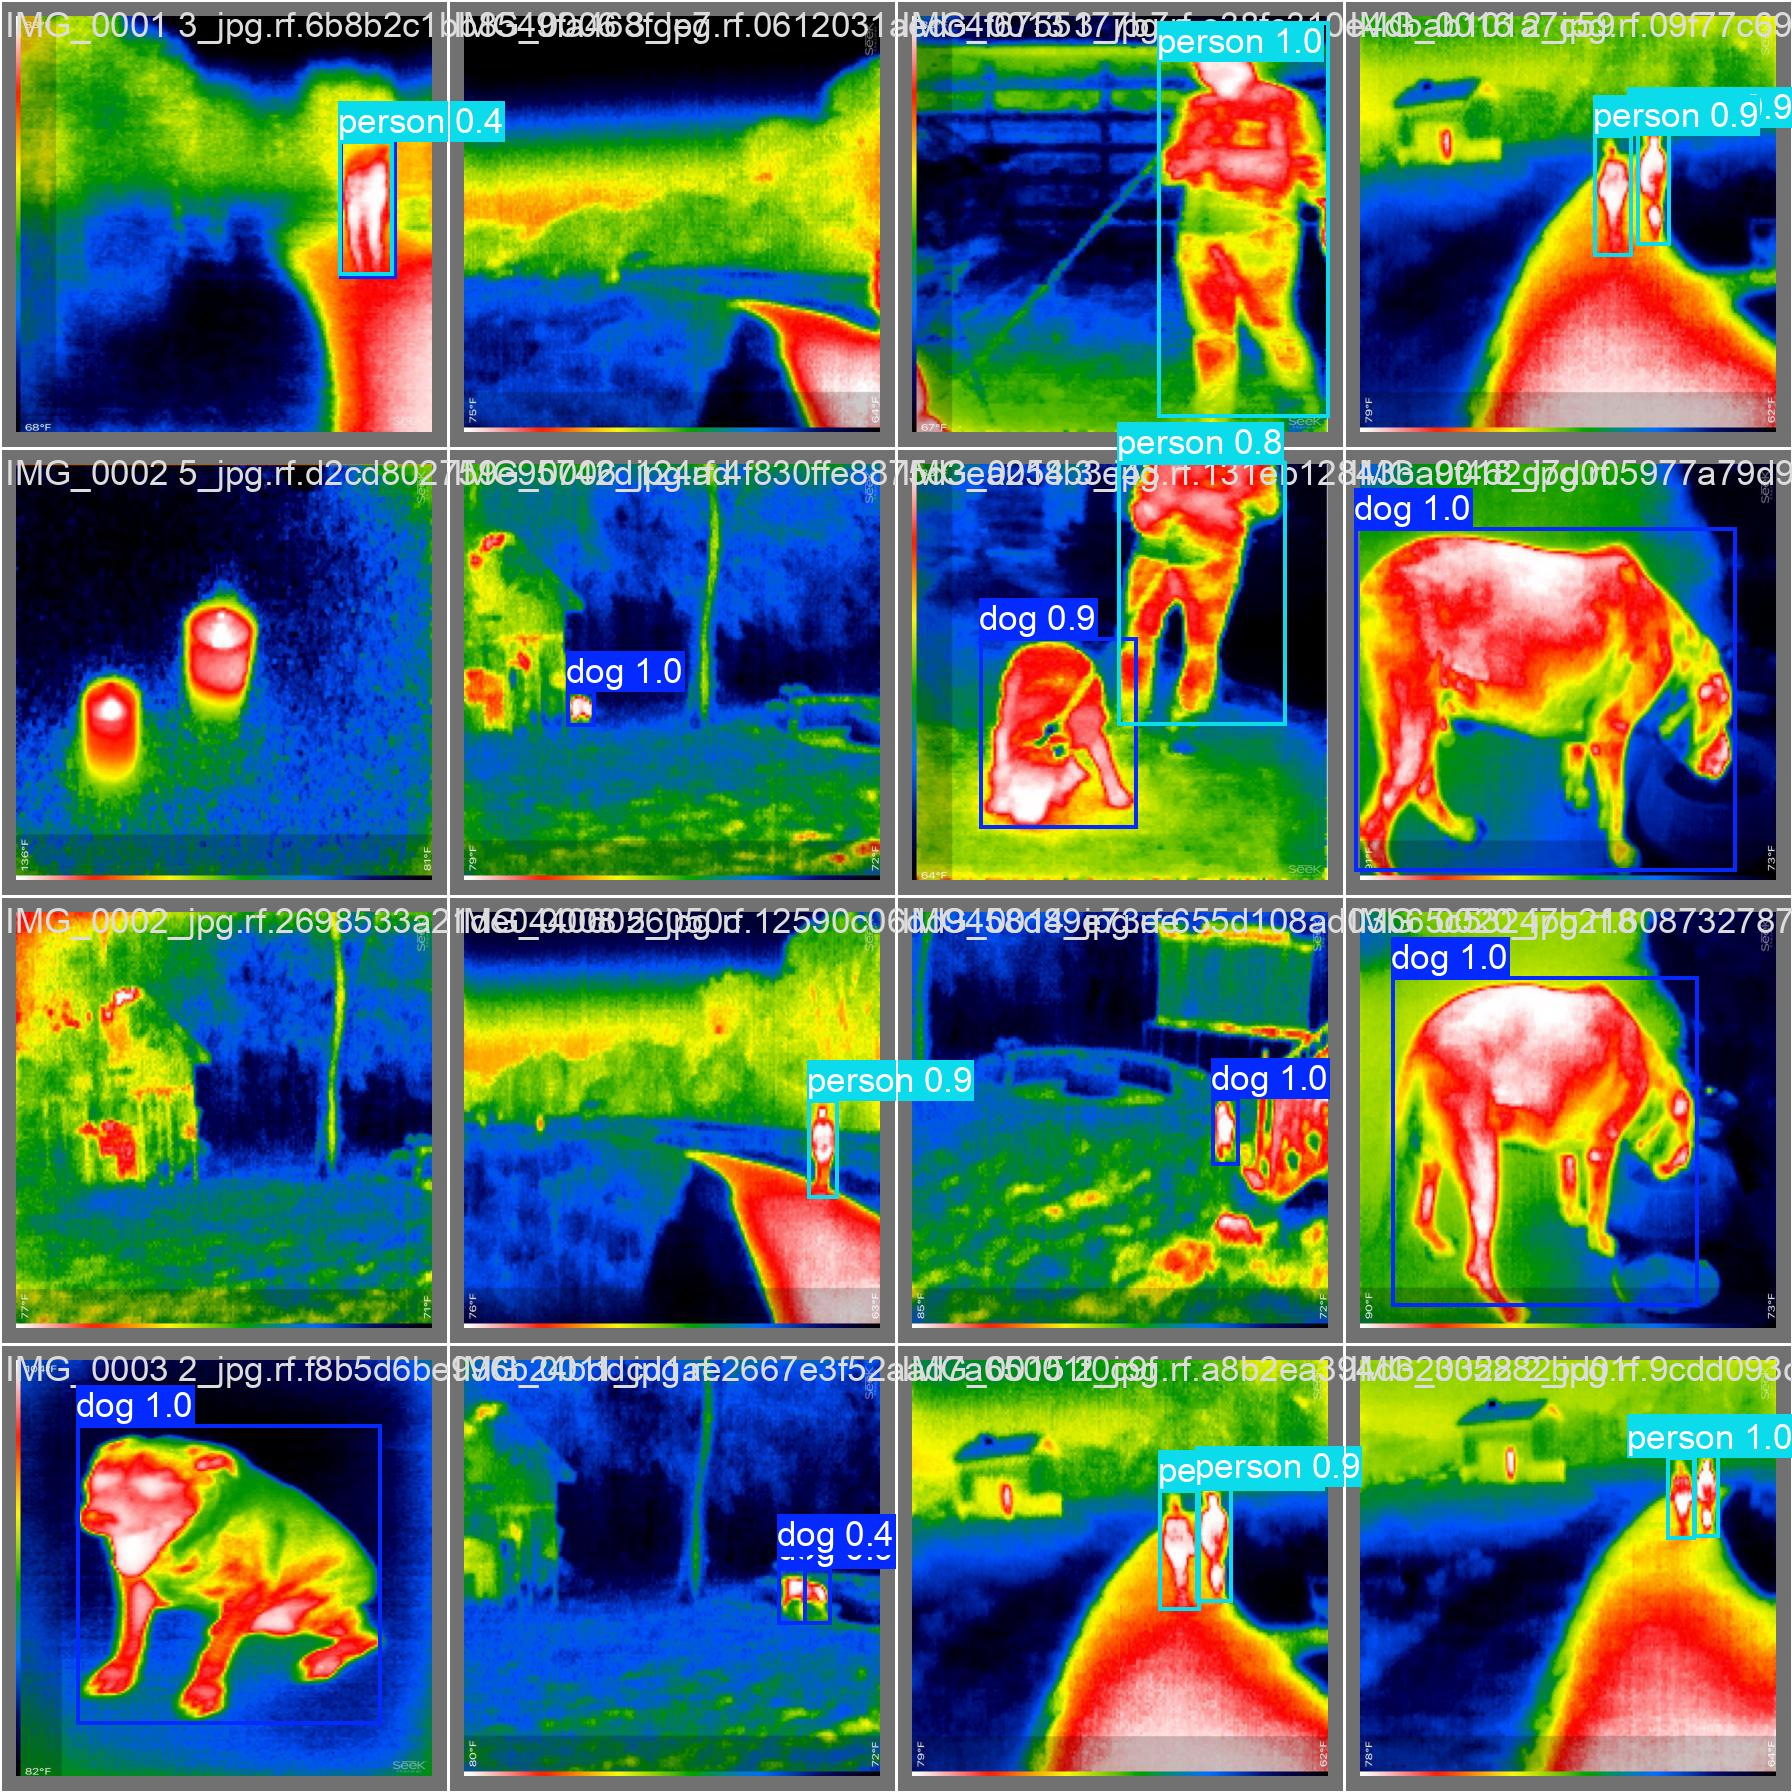

In [ ]:
Image(filename='/content/datasets/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model=/content/drive/MyDrive/SmartDronesFinal/train1/train/weights/best.pt data=/content/datasets/data.yaml

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
100% 755k/755k [00:00<00:00, 17.5MB/s]
val: Scanning /content/datasets/valid/labels... 41 images, 5 backgrounds, 0 corrupt: 100% 41/41 [00:00<00:00, 655.25it/s]
val: New cache created: /content/datasets/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:01<00:00,  1.61it/s]
                   all         41         49      0.991       0.88      0.972        0.8
                   dog         22         22          1      0.944      0.992      0.885
                person         19         27      0.983      0.815      0.952      0.714
Speed: 1.4ms preprocess, 6.9ms inference, 0.0ms loss, 7.6ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val
